In [1]:
import sys
print(sys.executable)

/Users/ahn/micromamba/envs/mpdag_env/bin/python


## Focusing 10 25 variables on target

In [15]:
import pandas as pd

# 1. Read skipping the junk top row, and ignore the index
target_10_25_ns_1000_er2 = pd.read_csv('experiment_runs/target_10_25_ns_1000_er2.csv', header=1)

# 2. Drop the first column if it's all NaNs (the "Unnamed: 0" in your pic)
target_10_25_ns_1000_er2 = target_10_25_ns_1000_er2.dropna(axis=1, how='all')

# 2. Forward fill the columns that contain merged cells
# This replaces NaN values with the last valid observation
target_10_25_ns_1000_er2['observed'] = target_10_25_ns_1000_er2['observed'].ffill()
target_10_25_ns_1000_er2['f1_without_b_mean'] = target_10_25_ns_1000_er2['f1_without_b_mean'].ffill()
target_10_25_ns_1000_er2['f1_without_b_std'] = target_10_25_ns_1000_er2['f1_without_b_std'].ffill()
target_10_25_ns_1000_er2['confidence_interval_without_b'] = target_10_25_ns_1000_er2['confidence_interval_without_b'].ffill()

# Create constant column for experimental degree
target_10_25_ns_1000_er2['exp_degree'] = 2

# Create constant column for number of samples
target_10_25_ns_1000_er2['n_samples'] = 1000

In [16]:
target_10_25_ns_1000_er2

,observed,n iterations,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,confidence_interval_with_b,f1_without_b_mean,f1_without_b_std,confidence_interval_without_b,exp_degree,n_samples
0,10.0,1000.0,0,0.2,0.764,0.385,0.024,0.713,0.421,0.026,2,1000
1,10.0,NaN,0,0.3,0.795,0.360,0.022,0.713,0.421,0.026,2,1000
2,10.0,NaN,0,0.4,0.808,0.351,0.022,0.713,0.421,0.026,2,1000
3,10.0,NaN,0,0.5,0.821,0.341,0.021,0.713,0.421,0.026,2,1000
4,15.0,NaN,0,0.2,0.779,0.366,0.023,0.749,0.389,0.024,2,1000
5,15.0,NaN,0,0.3,0.799,0.353,0.022,0.749,0.389,0.024,2,1000
6,15.0,NaN,0,0.4,0.801,0.353,0.022,0.749,0.389,0.024,2,1000
7,15.0,NaN,0,0.5,0.815,0.341,0.021,0.749,0.389,0.024,2,1000
8,20.0,NaN,0,0.2,0.764,0.371,0.023,0.744,0.387,0.024,2,1000
9,20.0,NaN,0,0.3,0.786,0.356,0.022,0.744,0.387,0.024,2,1000


In [18]:
df = pd.read_csv('experiment_runs/n_var_target_10_25/nsample_var_target_10_25_100.csv')
df

,observed,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,f1_without_b_mean,f1_without_b_std,f1_successful_with_b_mean,f1_successful_with_b_std,f1_successful_without_b_mean,f1_successful_without_b_std,f1_failed_without_b_mean,f1_failed_without_b_std
0,10,0.0,0.2,0.409595,0.453651,0.317938,0.435619,0.409595,0.453651,0.317938,0.435619,NaN,NaN
1,10,0.0,0.3,0.486370,0.459005,0.317938,0.435619,0.486370,0.459005,0.317938,0.435619,NaN,NaN
2,10,0.0,0.4,0.522811,0.456247,0.317938,0.435619,0.522811,0.456247,0.317938,0.435619,NaN,NaN
3,10,0.0,0.5,0.562494,0.450706,0.317938,0.435619,0.562494,0.450706,0.317938,0.435619,NaN,NaN
4,15,0.0,0.2,0.389861,0.449758,0.292214,0.421189,0.389861,0.449758,0.292214,0.421189,NaN,NaN
5,15,0.0,0.3,0.453919,0.456807,0.292214,0.421189,0.453919,0.456807,0.292214,0.421189,NaN,NaN
6,15,0.0,0.4,0.487545,0.456665,0.292214,0.421189,0.487545,0.456665,0.292214,0.421189,NaN,NaN
7,15,0.0,0.5,0.525323,0.454006,0.292214,0.421189,0.525323,0.454006,0.292214,0.421189,NaN,NaN
8,20,0.0,0.2,0.400976,0.443393,0.303657,0.425545,0.400976,0.443393,0.303657,0.425545,NaN,NaN
9,20,0.0,0.3,0.451848,0.447146,0.303657,0.425545,0.451848,0.447146,0.303657,0.425545,NaN,NaN


In [22]:
import glob
import os
import numpy as np

folder_path = 'experiment_runs/n_var_target_10_25/*.csv'
all_files = glob.glob(folder_path)
all_dfs = [target_10_25_ns_1000_er2]

for filepath in all_files:
    temp_df = pd.read_csv(filepath)
    
    # Metadata
    n_val = int(os.path.basename(filepath).split('_')[-1].replace('.csv', ''))
    temp_df['exp_degree'] = 2
    temp_df['n_samples'] = n_val
    
    # Calculate CI for this file (using hardcoded 1000 as requested)
    temp_df['confidence_interval_with_b'] = 1.96 * (temp_df['f1_with_b_std'] / np.sqrt(1000))
    temp_df['confidence_interval_without_b'] = 1.96 * (temp_df['f1_without_b_std'] / np.sqrt(1000))
    
    all_dfs.append(temp_df)

# --- 3. Final Concat ---
# Now all dataframes have the exact same columns in the same format
df_final = pd.concat(all_dfs, ignore_index=True)

In [25]:
# --- 2. Define the Collection ---
all_dfs = [df_final]

# Folder path (assuming both patterns might be in this folder or processed similarly)
folder_path = 'experiment_runs/ns_var_expd_var_target_10_25/*.csv'
all_files = glob.glob(folder_path)

for filepath in all_files:
    filename = os.path.basename(filepath)
    
    temp_df = pd.read_csv(filepath)
    clean_name = filename.replace('.csv', '')
    
    # --- Logic for the New Pattern: n100_deg3 ---
    if '_deg' in clean_name:
        parts = clean_name.split('_') # e.g., ['n100', 'deg3']
        n_val = int(parts[0].replace('n', '')) # 'n100' -> 100
        deg_val = int(parts[1].replace('deg', '')) # 'deg3' -> 3
        
    # --- Logic for the Old Pattern: nsample_var_target_10_25_100 ---
    else:
        n_val = int(clean_name.split('_')[-1])
        deg_val = 2 # Default for the first batch
    
    # Add metadata
    temp_df['exp_degree'] = deg_val
    temp_df['n_samples'] = n_val
    
    # Calculate CI consistently (Hardcoded 1000)
    temp_df['confidence_interval_with_b'] = 1.96 * (temp_df['f1_with_b_std'] / np.sqrt(1000))
    temp_df['confidence_interval_without_b'] = 1.96 * (temp_df['f1_without_b_std'] / np.sqrt(1000))
    
    all_dfs.append(temp_df)

# --- 3. Combine Everything ---
df_final = pd.concat(all_dfs, ignore_index=True)

In [26]:
df_final

,observed,n iterations,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,confidence_interval_with_b,f1_without_b_mean,f1_without_b_std,confidence_interval_without_b,exp_degree,n_samples,f1_successful_with_b_mean,f1_successful_with_b_std,f1_successful_without_b_mean,f1_successful_without_b_std,f1_failed_without_b_mean,f1_failed_without_b_std
0,10.0,1000.0,0.0,0.2,0.764000,0.385000,0.024000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
1,10.0,NaN,0.0,0.3,0.795000,0.360000,0.022000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,NaN,0.0,0.4,0.808000,0.351000,0.022000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,NaN,0.0,0.5,0.821000,0.341000,0.021000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
4,15.0,NaN,0.0,0.2,0.779000,0.366000,0.023000,0.749000,0.389000,0.024000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,20.0,NaN,0.0,0.5,0.459906,0.341586,0.021172,0.341366,0.336200,0.020838,6,5000,0.459906,0.341586,0.341366,0.336200,NaN,NaN
564,25.0,NaN,0.0,0.2,0.390969,0.328111,0.020337,0.345868,0.326936,0.020264,6,5000,0.390969,0.328111,0.345868,0.326936,NaN,NaN
565,25.0,NaN,0.0,0.3,0.413113,0.326552,0.020240,0.345868,0.326936,0.020264,6,5000,0.413113,0.326552,0.345868,0.326936,NaN,NaN
566,25.0,NaN,0.0,0.4,0.433975,0.328253,0.020345,0.345868,0.326936,0.020264,6,5000,0.433975,0.328253,0.345868,0.326936,NaN,NaN


In [28]:
# Create a new DataFrame for just this specific experiment setup
filtered_df = df_final[(df_final['n_samples'] == 100) & (df_final['exp_degree'] == 3)]

# View the results
filtered_df

,observed,n iterations,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,confidence_interval_with_b,f1_without_b_mean,f1_without_b_std,confidence_interval_without_b,exp_degree,n_samples,f1_successful_with_b_mean,f1_successful_with_b_std,f1_successful_without_b_mean,f1_successful_without_b_std,f1_failed_without_b_mean,f1_failed_without_b_std
280,10.0,NaN,0.0,0.2,0.287369,0.398849,0.024721,0.190183,0.347776,0.021555,3,100,0.287369,0.398849,0.190183,0.347776,NaN,NaN
281,10.0,NaN,0.0,0.3,0.337663,0.411288,0.025492,0.190183,0.347776,0.021555,3,100,0.337663,0.411288,0.190183,0.347776,NaN,NaN
282,10.0,NaN,0.0,0.4,0.384132,0.418126,0.025916,0.190183,0.347776,0.021555,3,100,0.384132,0.418126,0.190183,0.347776,NaN,NaN
283,10.0,NaN,0.0,0.5,0.430767,0.423283,0.026235,0.190183,0.347776,0.021555,3,100,0.430767,0.423283,0.190183,0.347776,NaN,NaN
284,15.0,NaN,0.0,0.2,0.274205,0.390014,0.024173,0.190135,0.347137,0.021516,3,100,0.274205,0.390014,0.190135,0.347137,NaN,NaN
285,15.0,NaN,0.0,0.3,0.339084,0.407115,0.025233,0.190135,0.347137,0.021516,3,100,0.339084,0.407115,0.190135,0.347137,NaN,NaN
286,15.0,NaN,0.0,0.4,0.366698,0.413170,0.025609,0.190135,0.347137,0.021516,3,100,0.366698,0.413170,0.190135,0.347137,NaN,NaN
287,15.0,NaN,0.0,0.5,0.405445,0.420158,0.026042,0.190135,0.347137,0.021516,3,100,0.405445,0.420158,0.190135,0.347137,NaN,NaN
288,20.0,NaN,0.0,0.2,0.264026,0.379993,0.023552,0.179625,0.338842,0.021002,3,100,0.264026,0.379993,0.179625,0.338842,NaN,NaN
289,20.0,NaN,0.0,0.3,0.312329,0.394547,0.024454,0.179625,0.338842,0.021002,3,100,0.312329,0.394547,0.179625,0.338842,NaN,NaN


In [29]:
# Create a new DataFrame for just this specific experiment setup
filtered_df = df_final[(df_final['n_samples'] == 10000) & (df_final['exp_degree'] == 5)]

# View the results
filtered_df

,observed,n iterations,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,confidence_interval_with_b,f1_without_b_mean,f1_without_b_std,confidence_interval_without_b,exp_degree,n_samples,f1_successful_with_b_mean,f1_successful_with_b_std,f1_successful_without_b_mean,f1_successful_without_b_std,f1_failed_without_b_mean,f1_failed_without_b_std
424,10.0,NaN,0.0,0.2,0.427040,0.398957,0.024728,0.354356,0.392041,0.024299,5,10000,0.427040,0.398957,0.354356,0.392041,NaN,NaN
425,10.0,NaN,0.0,0.3,0.465076,0.394567,0.024456,0.354356,0.392041,0.024299,5,10000,0.465076,0.394567,0.354356,0.392041,NaN,NaN
426,10.0,NaN,0.0,0.4,0.504198,0.393303,0.024377,0.354356,0.392041,0.024299,5,10000,0.504198,0.393303,0.354356,0.392041,NaN,NaN
427,10.0,NaN,0.0,0.5,0.538531,0.388378,0.024072,0.354356,0.392041,0.024299,5,10000,0.538531,0.388378,0.354356,0.392041,NaN,NaN
428,15.0,NaN,0.0,0.2,0.470429,0.377237,0.023381,0.418198,0.376194,0.023317,5,10000,0.470429,0.377237,0.418198,0.376194,NaN,NaN
429,15.0,NaN,0.0,0.3,0.500715,0.373500,0.023150,0.418198,0.376194,0.023317,5,10000,0.500715,0.373500,0.418198,0.376194,NaN,NaN
430,15.0,NaN,0.0,0.4,0.531634,0.366354,0.022707,0.418198,0.376194,0.023317,5,10000,0.531634,0.366354,0.418198,0.376194,NaN,NaN
431,15.0,NaN,0.0,0.5,0.555348,0.361182,0.022386,0.418198,0.376194,0.023317,5,10000,0.555348,0.361182,0.418198,0.376194,NaN,NaN
432,20.0,NaN,0.0,0.2,0.478189,0.361093,0.022381,0.440922,0.367229,0.022761,5,10000,0.478189,0.361093,0.440922,0.367229,NaN,NaN
433,20.0,NaN,0.0,0.3,0.505267,0.359951,0.022310,0.440922,0.367229,0.022761,5,10000,0.505267,0.359951,0.440922,0.367229,NaN,NaN


In [30]:
# Create a new DataFrame for just this specific experiment setup
filtered_df = df_final[(df_final['observed'] <= 25)]

# View the results
filtered_df

,observed,n iterations,fraction_forbidden,fraction_required,f1_with_b_mean,f1_with_b_std,confidence_interval_with_b,f1_without_b_mean,f1_without_b_std,confidence_interval_without_b,exp_degree,n_samples,f1_successful_with_b_mean,f1_successful_with_b_std,f1_successful_without_b_mean,f1_successful_without_b_std,f1_failed_without_b_mean,f1_failed_without_b_std
0,10.0,1000.0,0.0,0.2,0.764000,0.385000,0.024000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
1,10.0,NaN,0.0,0.3,0.795000,0.360000,0.022000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,NaN,0.0,0.4,0.808000,0.351000,0.022000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,NaN,0.0,0.5,0.821000,0.341000,0.021000,0.713000,0.421000,0.026000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
4,15.0,NaN,0.0,0.2,0.779000,0.366000,0.023000,0.749000,0.389000,0.024000,2,1000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,20.0,NaN,0.0,0.5,0.459906,0.341586,0.021172,0.341366,0.336200,0.020838,6,5000,0.459906,0.341586,0.341366,0.336200,NaN,NaN
564,25.0,NaN,0.0,0.2,0.390969,0.328111,0.020337,0.345868,0.326936,0.020264,6,5000,0.390969,0.328111,0.345868,0.326936,NaN,NaN
565,25.0,NaN,0.0,0.3,0.413113,0.326552,0.020240,0.345868,0.326936,0.020264,6,5000,0.413113,0.326552,0.345868,0.326936,NaN,NaN
566,25.0,NaN,0.0,0.4,0.433975,0.328253,0.020345,0.345868,0.326936,0.020264,6,5000,0.433975,0.328253,0.345868,0.326936,NaN,NaN


Choosing Your X-Axis: The "Statistical Power" Metric

When evaluating causal learning algorithms, the difficulty of the task generally increases with the number of variables (nodes) and the density of the graph (expected degree), while it decreases as you provide more data samples.The most principled way to fuse n_samples, exp_degree, and observed is to calculate the Samples per Expected Edge.In a causal graph, the total expected number of edges $E$ is roughly $\frac{\text{observed} \times \text{exp\_degree}}{2}$. Therefore, a great unified metric for your x-axis is:$$X = \frac{\text{n\_samples}}{\text{observed} \times \text{exp\_degree} / 2}$$This metric represents the statistical power available per structural parameter you are trying to learn. A low value means the algorithm is starved for data relative to the graph's complexity, while a high value represents an "easy" regime.

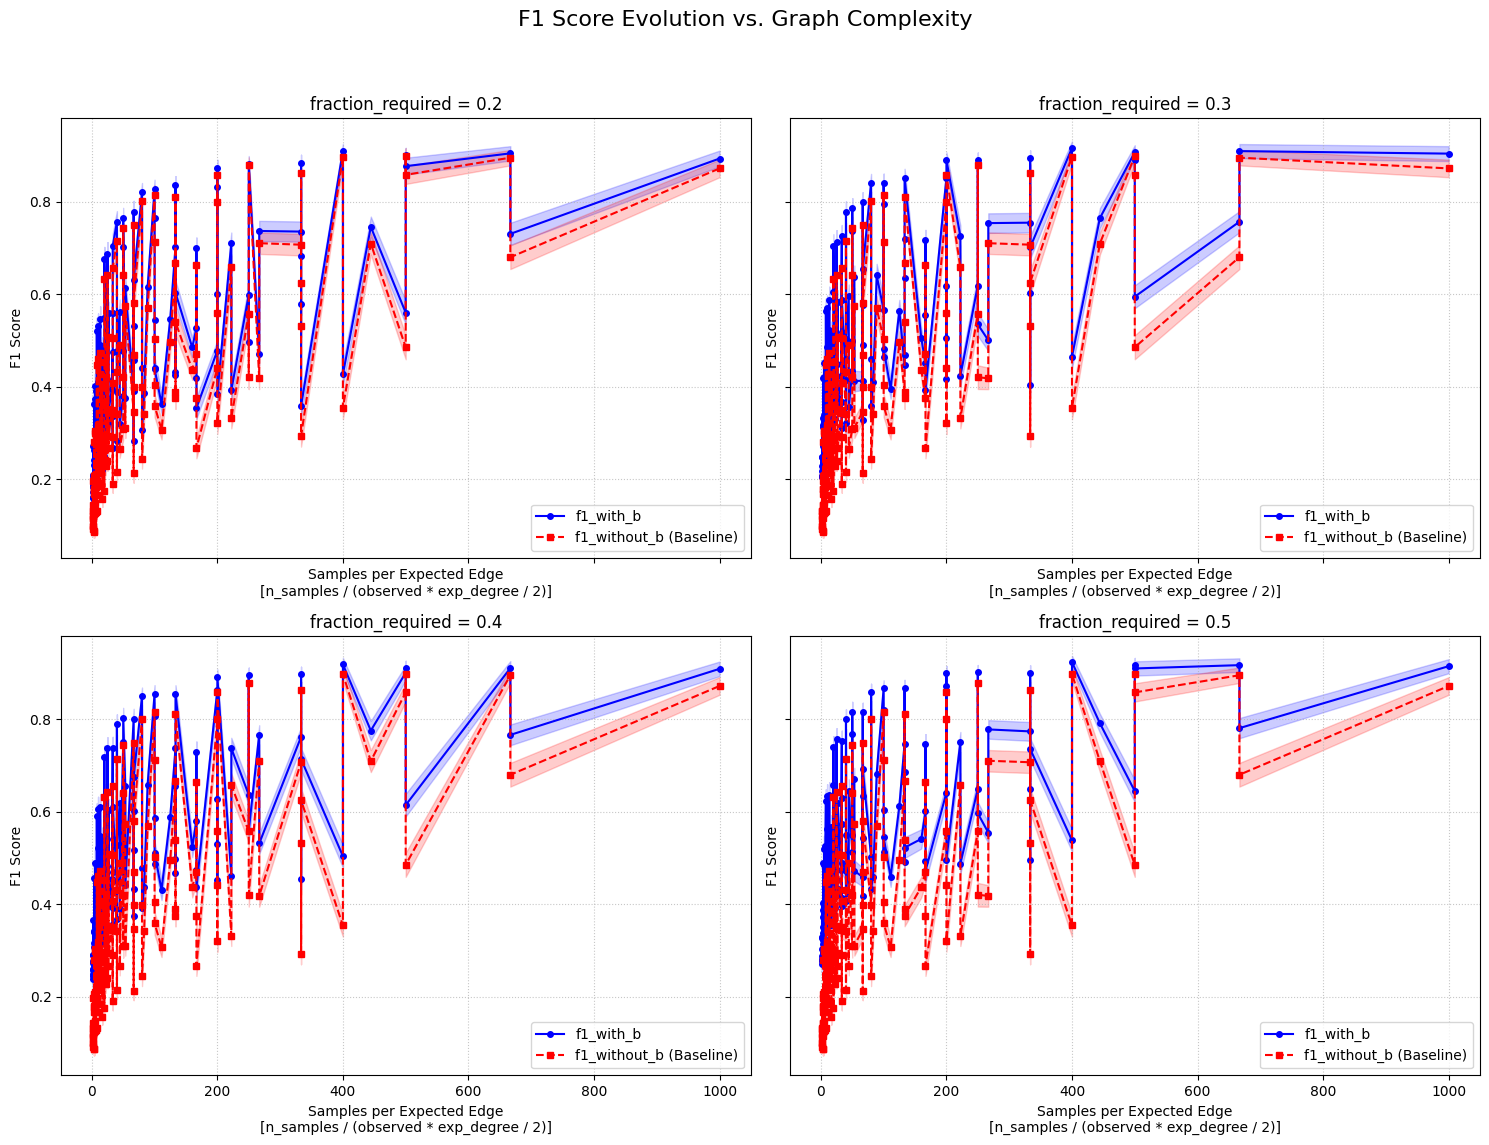

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is named 'filtered_df'
df = filtered_df.copy()

# 1. Create the unified X-axis metric (Samples per Expected Edge)
df['complexity_metric'] = df['n_samples'] / ((df['observed'] * df['exp_degree']) / 2)

# Sort the dataframe by this new metric so the line plots connect points sequentially
df = df.sort_values(by='complexity_metric')

# 2. Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True, sharey=True)
fig.suptitle('F1 Score Evolution vs. Graph Complexity', fontsize=16)

# The fractions you want to plot
fractions = [0.2, 0.3, 0.4, 0.5]

for ax, frac in zip(axes.flatten(), fractions):
    # Filter for the current fraction
    subset = df[df['fraction_required'] == frac]
    
    # Extract X
    x = subset['complexity_metric']
    
    # Extract Y values and Confidence Intervals for 'With B'
    y_with = subset['f1_with_b_mean']
    ci_with = subset['confidence_interval_with_b'] 
    
    # Extract Y values and Confidence Intervals for 'Without B'
    # (Since it's constant for the triplet, it just maps to the same X axis)
    y_without = subset['f1_without_b_mean']
    ci_without = subset['confidence_interval_without_b']
    
    # Plot 'f1_with_b'
    ax.plot(x, y_with, label='f1_with_b', color='blue', marker='o', markersize=4)
    # Note: If your CI column is a margin (e.g., +/- 0.05), use this logic:
    ax.fill_between(x, y_with - ci_with, y_with + ci_with, color='blue', alpha=0.2)
    
    # Plot 'f1_without_b' (Baseline)
    ax.plot(x, y_without, label='f1_without_b (Baseline)', color='red', linestyle='--', marker='s', markersize=4)
    ax.fill_between(x, y_without - ci_without, y_without + ci_without, color='red', alpha=0.2)
    
    # Formatting
    ax.set_title(f'fraction_required = {frac}')
    ax.set_xlabel('Samples per Expected Edge\n[n_samples / (observed * exp_degree / 2)]')
    ax.set_ylabel('F1 Score')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower right')

# Use a logarithmic scale if your sample sizes span multiple orders of magnitude
# plt.xscale('log') 

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit the suptitle
plt.show()

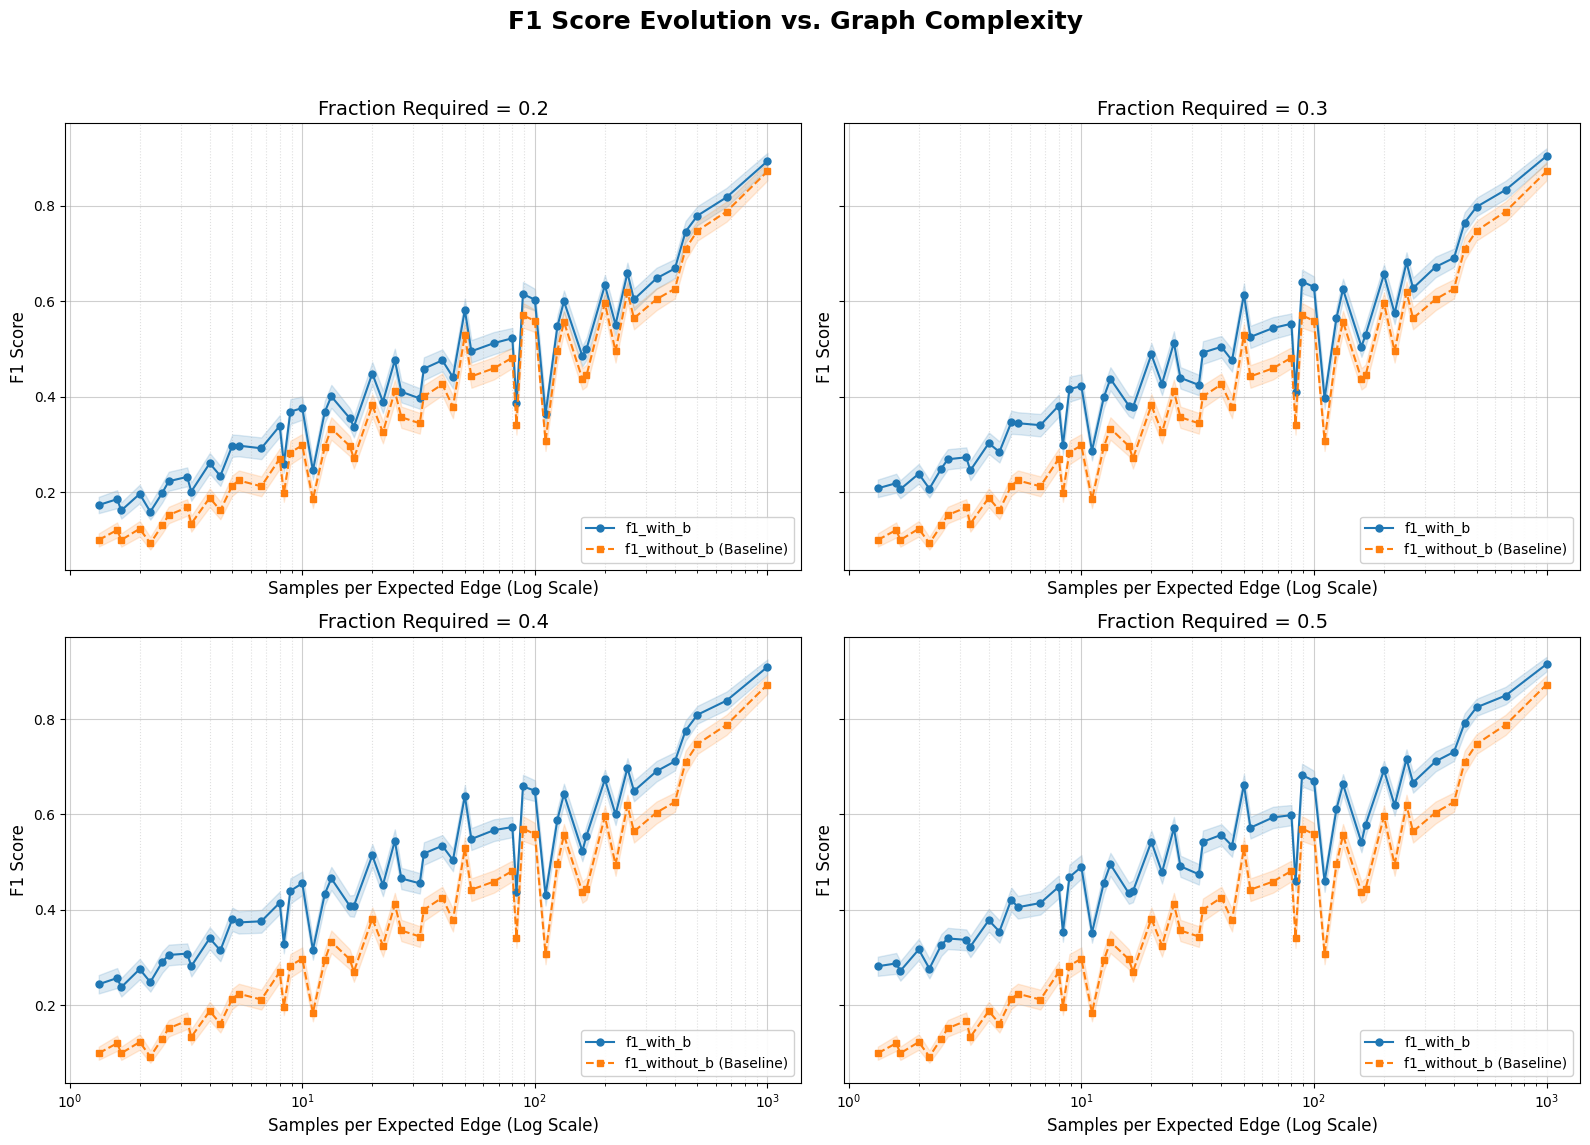

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is named 'filtered_df'
df = filtered_df.copy()

# 1. Create the unified X-axis metric
df['complexity_metric'] = df['n_samples'] / ((df['observed'] * df['exp_degree']) / 2)

# 2. CRITICAL FIX: Aggregate overlapping X-values
# This groups by the fraction and the complexity metric, then takes the mean.
# This prevents the vertical "zig-zag" lines.
agg_df = df.groupby(['fraction_required', 'complexity_metric']).mean().reset_index()

# 3. Set up the 2x2 grid with better sizing
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('F1 Score Evolution vs. Graph Complexity', fontsize=18, fontweight='bold')

fractions = [0.2, 0.3, 0.4, 0.5]
colors = {'with': '#1f77b4', 'without': '#ff7f0e'} # Softer blue and orange/red

for ax, frac in zip(axes.flatten(), fractions):
    # Filter and sort the aggregated data
    subset = agg_df[agg_df['fraction_required'] == frac].sort_values('complexity_metric')
    
    x = subset['complexity_metric']
    y_with = subset['f1_with_b_mean']
    ci_with = subset['confidence_interval_with_b'] 
    y_without = subset['f1_without_b_mean']
    ci_without = subset['confidence_interval_without_b']
    
    # Plot 'f1_with_b'
    ax.plot(x, y_with, label='f1_with_b', color=colors['with'], marker='o', markersize=5, linewidth=1.5)
    ax.fill_between(x, y_with - ci_with, y_with + ci_with, color=colors['with'], alpha=0.15)
    
    # Plot 'f1_without_b'
    ax.plot(x, y_without, label='f1_without_b (Baseline)', color=colors['without'], linestyle='--', marker='s', markersize=5, linewidth=1.5)
    ax.fill_between(x, y_without - ci_without, y_without + ci_without, color=colors['without'], alpha=0.15)
    
    # Formatting
    ax.set_title(f'Fraction Required = {frac}', fontsize=14)
    ax.set_ylabel('F1 Score', fontsize=12)
    
    # CRITICAL FIX: Log Scale for X-axis
    ax.set_xscale('log')
    ax.set_xlabel('Samples per Expected Edge (Log Scale)', fontsize=12)
    
    # Improved grid lines (both major and minor for log scale)
    ax.grid(True, which="major", linestyle='-', alpha=0.6)
    ax.grid(True, which="minor", linestyle=':', alpha=0.4)
    
    ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Results on noised data

In [3]:
"""
Load all CSVs from experiment_runs/normal_tar_er2_d10_25_mu01_05,
parse metadata from filenames, build a unified DataFrame, then plot
each metric vs complexity_metric for each noise level (false_ratio).

File naming convention:  n{N}_deg{D}_d{d}_fr{fr}.csv
  N   = n_samples (but also in the CSV)
  D   = exp_degree
  d   = observed variables
  fr  = false_ratio (noise level)
"""

import re
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Config ───────────────────────────────────────────────────────────────────
DIR        = "experiment_runs/normal_tar_er2_d10_25_mu01_05"
OUTPUT_DIR = "plots_noised"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NOISE_LEVELS = [0.1, 0.2, 0.3, 0.5]   # false_ratio values to plot

METRICS = ["f1", "int_dist"]
METRIC_LABELS = {"f1": "F1 Score", "int_dist": "Int. Distance"}

# ── 1. Load & concatenate all CSVs ──────────────────────────────────────────
pattern = os.path.join(DIR, "**", "*.csv")
files   = glob.glob(pattern, recursive=True)
if not files:
    # also try flat
    files = glob.glob(os.path.join(DIR, "*.csv"))

print(f"Found {len(files)} CSV files.")

dfs = []
for fpath in files:
    fname = os.path.basename(fpath)
    # parse false_ratio from filename  e.g. n100_deg2_d10_fr0.1.csv
    match = re.search(r"fr([0-9]+\.?[0-9]*)", fname)
    if match is None:
        print(f"  WARNING: could not parse fr from {fname}, skipping.")
        continue
    false_ratio = float(match.group(1))

    df_tmp = pd.read_csv(fpath)
    df_tmp["false_ratio"] = false_ratio
    df_tmp["source_file"] = fname
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {df.shape}")
print(df.head(3).to_string())

# ── 2. Complexity metric ─────────────────────────────────────────────────────
df["complexity_metric"] = df["n_samples"] / ((df["observed"] * df["exp_degree"]) / 2)

# ── 3. Plot ──────────────────────────────────────────────────────────────────
# One figure per noise level; inside: subplots for each metric
# Each subplot shows with_b (blue) and without_b (orange) mean lines

CMAP_WITH    = cm.Blues
CMAP_WITHOUT = cm.Oranges

# We'll also group by any remaining categorical variables if present
# (e.g. fraction_required); use it as line hue within each subplot
HUE_COL = "fraction_required"

for fr in NOISE_LEVELS:
    sub = df[np.isclose(df["false_ratio"], fr)]
    if sub.empty:
        print(f"No data for false_ratio={fr}, skipping.")
        continue

    fracs = sorted(sub[HUE_COL].unique()) if HUE_COL in sub.columns else [None]
    n     = len(fracs)
    colors_with    = [CMAP_WITH(0.35 + 0.55 * i / max(n - 1, 1)) for i in range(n)]
    colors_without = [CMAP_WITHOUT(0.35 + 0.55 * i / max(n - 1, 1)) for i in range(n)]

    fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4.5), sharey=False)
    if len(METRICS) == 1:
        axes = [axes]
    fig.suptitle(f"Noise level (false_ratio) = {fr}", fontsize=14, fontweight="bold", y=1.01)

    for ax, metric in zip(axes, METRICS):
        col_with    = f"{metric}_with_b_mean"
        col_without = f"{metric}_without_b_mean"

        for i, frac in enumerate(fracs):
            if frac is not None:
                grp = sub[np.isclose(sub[HUE_COL], frac)].sort_values("complexity_metric")
            else:
                grp = sub.sort_values("complexity_metric")

            x = grp["complexity_metric"].values

            if col_with in grp.columns:
                ax.plot(x, grp[col_with].values, color=colors_with[i], marker="o",
                        linewidth=1.8, markersize=4,
                        label=f"with_b  frac_req={frac:.1f}" if frac is not None else "with_b")

            if col_without in grp.columns:
                ax.plot(x, grp[col_without].values, color=colors_without[i], marker="s",
                        linewidth=1.8, markersize=4, linestyle="--",
                        label=f"w/o_b   frac_req={frac:.1f}" if frac is not None else "w/o_b")

        ax.set_title(METRIC_LABELS[metric], fontsize=11)
        ax.set_xlabel("Samples per Expected Edge\n(n_samples / ((observed × exp_degree) / 2))", fontsize=8)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.06),
               ncol=min(n * 2, 6), fontsize=7,
               title="Blue solid = with_b   |   Orange dashed = without_b",
               title_fontsize=8)

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/noised_fr{str(fr).replace('.', '')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {fname}")

# ── 4. Save combined DataFrame ───────────────────────────────────────────────
out_csv = os.path.join(OUTPUT_DIR, "combined_noised_results.csv")
df.to_csv(out_csv, index=False)
print(f"Combined CSV saved: {out_csv}")
print("Done.")

Found 112 CSV files.
Combined shape: (1008, 15)
   observed  exp_degree  n_samples  fraction_forbidden  fraction_required  f1_with_b_mean  f1_with_b_std  f1_without_b_mean  f1_without_b_std  int_dist_with_b_mean  int_dist_with_b_std  int_dist_without_b_mean  int_dist_without_b_std  false_ratio               source_file
0        25         2.0       5000                 0.0                0.1        0.816356       0.322015           0.859088          0.306753              0.093575             0.491592                 0.085601                0.495047          0.5  n5000_deg2_d25_fr0.5.csv
1        25         2.0       5000                 0.0                0.2        0.809722       0.326749           0.859088          0.306753              0.113147             0.586716                 0.085601                0.495047          0.5  n5000_deg2_d25_fr0.5.csv
2        25         2.0       5000                 0.0                0.3        0.783163       0.335121           0.859088          

# Results on PC basline models

## On synthetic data

Results of applying the PC and b-PC baseline models are in experiment_runs/pc/ (pc_d10_25 for PC results on synthetic graph configurations, eg er2_n100_d10.csv is for ER2 graph, 100 data samples and 10 observed variables, pc_tar_d10_25 for b-pc using local background knowledge strategy). Unlike other result tables, here pc and b-pc are seperated; that means that unlike b-pc or other results where there is a line for each fraction required proportion, pc has just one line per result on a given synthetic graph configurationj

Results of LOAD and b-LOAD models on similar graph configurations can be seen in two areas:
1. experiment_runs/normal/ER2 - ER6: the results of the runs are saved as csv files within a hierarchy of subdirectories: ex: ER2/n100 (number of data samples)/ d10.csv (10 observed nodes)
2. experiment_runs/normal/normal_tar_er5_6_d10_50; here the results of each run are in csv files following similar nomenclature to the pc results with the exception that ER is replaced by deg (eg n100_deg5_d10.csv represents a synthetic graph of 100 data samples, ER5 and number of nodes equal to 10)

concatenate all the results and make similar graphs to what is seen at the end of "Focusing 10 25 variables on target" section:
- for each proportion of exposed background knowledge i want two graphs: one where the f1 scores are compared between pc, b-pc, load and b-load, and another that's identical but for intervention distance. The column names are systematically: observed	exp_degree	n_samples	fraction_forbidden	fraction_required	f1_with_b_mean	f1_with_b_std	f1_without_b_mean	f1_without_b_std	int_dist_with_b_mean	int_dist_with_b_std	int_dist_without_b_mean	int_dist_without_b_std
- the confidence intervals have to be computed based on the std but also given that 1000 iterations were done for each result. Similarly to what has been above:     # Calculate CI consistently (Hardcoded 1000)
    temp_df['confidence_interval_with_b'] = 1.96 * (temp_df['f1_with_b_std'] / np.sqrt(1000))
    temp_df['confidence_interval_without_b'] = 1.96 * (temp_df['f1_without_b_std'] / np.sqrt(1000))

In [7]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load PC results (no background knowledge) ─────────────────────────────
pc_files = glob.glob('../experiment_runs/baseline/pc/pc_d10_25/*.csv')
df_pc = pd.concat([pd.read_csv(f) for f in pc_files], ignore_index=True)
print(f"PC:                  {df_pc.shape[0]:>5} rows")

# ── 2. Load b-PC results (local background knowledge sampling) ────────────────
bpc_files = glob.glob('../experiment_runs/baseline/pc/pc_tar_d10_25/*.csv')
df_bpc = pd.concat([pd.read_csv(f) for f in bpc_files], ignore_index=True)
print(f"b-PC (local):        {df_bpc.shape[0]:>5} rows")

# ── 3. Load LOAD results — ER2–ER6 subdirectory hierarchy ────────────────────
load_er_files = glob.glob('../experiment_runs/normal/ER*/**/*.csv', recursive=True)
df_load_er = pd.concat([pd.read_csv(f) for f in load_er_files], ignore_index=True)
print(f"LOAD (ER hierarchy): {df_load_er.shape[0]:>5} rows")

# ── 4. Load extra LOAD results — ER5/ER6, d10–50 ─────────────────────────────
load_extra_files = glob.glob('../experiment_runs/normal/normal_tar_er5_6_d10_50/*.csv')
df_load_extra = pd.concat([pd.read_csv(f) for f in load_extra_files], ignore_index=True)
print(f"LOAD (ER5/6 extra):  {df_load_extra.shape[0]:>5} rows")

# ── 5. Combine LOAD sources, drop exact duplicates ───────────────────────────
df_load = pd.concat([df_load_er, df_load_extra], ignore_index=True)
key_cols = ['observed', 'exp_degree', 'n_samples', 'fraction_required', 'fraction_forbidden']
df_load = df_load.drop_duplicates(subset=key_cols)
print(f"LOAD (combined):     {df_load.shape[0]:>5} rows")
print()
print("b-PC fraction_required values:", sorted(df_bpc['fraction_required'].unique()))
print("LOAD fraction_required values:", sorted(df_load['fraction_required'].unique()))

PC:                    140 rows
b-PC (local):         1260 rows
LOAD (ER hierarchy):   815 rows
LOAD (ER5/6 extra):    498 rows
LOAD (combined):      1254 rows

b-PC fraction_required values: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
LOAD fraction_required values: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]


In [8]:
# ── Complexity metric: samples per expected edge ──────────────────────────────
for df in [df_pc, df_bpc, df_load]:
    df['complexity_metric'] = df['n_samples'] / ((df['observed'] * df['exp_degree']) / 2)

# ── 95% confidence intervals (1000 iterations assumed throughout) ─────────────
N_ITER = 1000

df_pc['ci_f1']       = 1.96 * df_pc['f1_std']       / np.sqrt(N_ITER)
df_pc['ci_int_dist'] = 1.96 * df_pc['int_dist_std']  / np.sqrt(N_ITER)

df_bpc['ci_f1']       = 1.96 * df_bpc['f1_std']       / np.sqrt(N_ITER)
df_bpc['ci_int_dist'] = 1.96 * df_bpc['int_dist_std'] / np.sqrt(N_ITER)

df_load['ci_f1_with_b']          = 1.96 * df_load['f1_with_b_std']          / np.sqrt(N_ITER)
df_load['ci_f1_without_b']       = 1.96 * df_load['f1_without_b_std']       / np.sqrt(N_ITER)
df_load['ci_int_dist_with_b']    = 1.96 * df_load['int_dist_with_b_std']    / np.sqrt(N_ITER)
df_load['ci_int_dist_without_b'] = 1.96 * df_load['int_dist_without_b_std'] / np.sqrt(N_ITER)

# ── LOAD without-BK baseline: one row per (observed, exp_degree, n_samples) ──
# f1_without_b_mean is identical across fraction_required for the same config,
# so we just keep the first occurrence per config.
_load_no_bk_cols = [
    'observed', 'exp_degree', 'n_samples', 'complexity_metric',
    'f1_without_b_mean',    'ci_f1_without_b',
    'int_dist_without_b_mean', 'ci_int_dist_without_b',
]
df_load_no_bk = (
    df_load
    .drop_duplicates(subset=['observed', 'exp_degree', 'n_samples'])
    [_load_no_bk_cols]
    .copy()
)

print("Complexity metric range (PC):",
      f"{df_pc['complexity_metric'].min():.1f} – {df_pc['complexity_metric'].max():.1f}")
print("Complexity metric range (LOAD):",
      f"{df_load['complexity_metric'].min():.1f} – {df_load['complexity_metric'].max():.1f}")

Complexity metric range (PC): 1.3 – 1000.0
Complexity metric range (LOAD): 0.7 – 1000.0


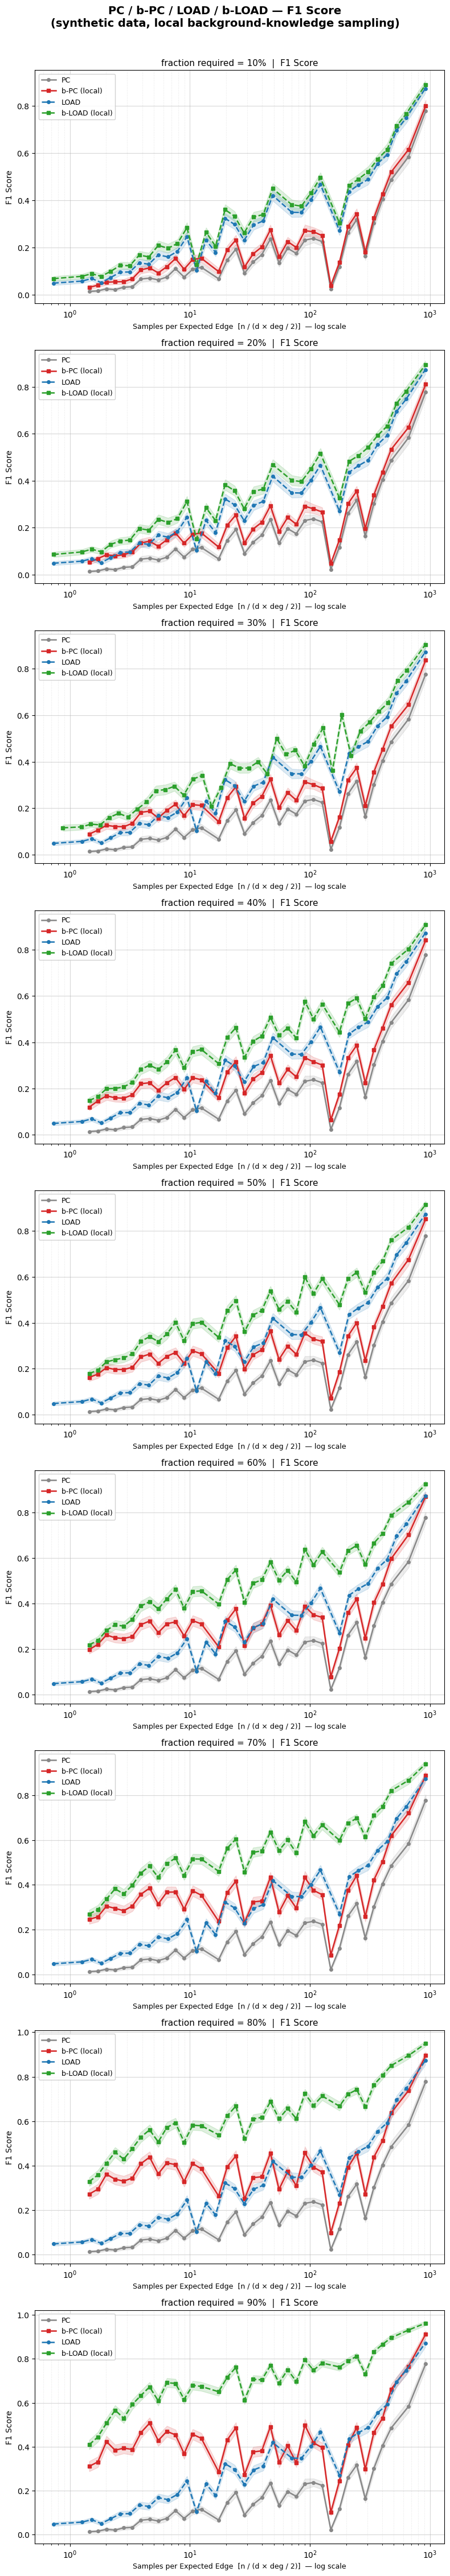

In [12]:
# ── Helper: bin by complexity_metric, then aggregate ─────────────────────────
def _agg_by_cx(df, cx_col='complexity_metric', mean_col=None, ci_col=None,
               n_bins=40):
    """
    Assign each row to one of n_bins log-spaced bins of cx_col, then take
    the mean within each bin.  Removes zigzag from many configs sharing the
    same complexity ratio.
    """
    lo = df[cx_col].min()
    hi = df[cx_col].max()
    if lo <= 0:
        lo = df[cx_col][df[cx_col] > 0].min()
    bins = np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
    df = df.copy()
    df['_bin'] = pd.cut(df[cx_col], bins=bins, labels=False, include_lowest=True)
    df['_bin_mid'] = df['_bin'].map(
        lambda b: np.sqrt(bins[int(b)] * bins[int(b) + 1]) if pd.notna(b) else np.nan
    )
    out = (
        df.dropna(subset=['_bin'])
        .groupby('_bin_mid')[[mean_col, ci_col]]
        .mean()
        .reset_index()
        .rename(columns={'_bin_mid': cx_col})
        .sort_values(cx_col)
    )
    return out

# ── Static aggregates (BK-independent) ───────────────────────────────────────
agg_pc_f1 = _agg_by_cx(df_pc,         mean_col='f1_mean',          ci_col='ci_f1')
agg_lo_f1 = _agg_by_cx(df_load_no_bk, mean_col='f1_without_b_mean', ci_col='ci_f1_without_b')

# ── Plot config ───────────────────────────────────────────────────────────────
FRACS = sorted(df_bpc['fraction_required'].unique())

COLORS = {
    'pc':    '#888888',   # grey  — PC (no BK)
    'bpc':   '#d62728',   # red   — b-PC
    'load':  '#1f77b4',   # blue  — LOAD (no BK)
    'bload': '#2ca02c',   # green — b-LOAD
}

fig, axes = plt.subplots(
    len(FRACS), 1,
    figsize=(8, 5 * len(FRACS)),
    sharey=False,
)
fig.suptitle(
    'PC / b-PC / LOAD / b-LOAD — F1 Score\n'
    '(synthetic data, local background-knowledge sampling)',
    fontsize=14, fontweight='bold', y=1.005,
)

def _plot(ax, df_agg, mean_col, ci_col, color, label,
          linestyle='-', marker='o', ci_alpha=0.15):
    x  = df_agg['complexity_metric']
    y  = df_agg[mean_col]
    ci = df_agg[ci_col]
    ax.plot(x, y, color=color, label=label,
            linestyle=linestyle, marker=marker, markersize=4, linewidth=1.8)
    ax.fill_between(x, y - ci, y + ci, color=color, alpha=ci_alpha)

for row, frac in enumerate(FRACS):
    ax = axes[row]

    sub_bpc  = df_bpc[np.isclose(df_bpc['fraction_required'],  frac)]
    sub_load = df_load[np.isclose(df_load['fraction_required'], frac)]

    # PC — grey solid
    _plot(ax, agg_pc_f1, 'f1_mean', 'ci_f1',
          COLORS['pc'], 'PC', linestyle='-', marker='o')

    # b-PC — red solid
    if not sub_bpc.empty:
        agg_bpc = _agg_by_cx(sub_bpc, mean_col='f1_mean', ci_col='ci_f1')
        _plot(ax, agg_bpc, 'f1_mean', 'ci_f1',
              COLORS['bpc'], 'b-PC (local)', linestyle='-', marker='s')

    # LOAD (no BK) — blue dashed
    _plot(ax, agg_lo_f1, 'f1_without_b_mean', 'ci_f1_without_b',
          COLORS['load'], 'LOAD', linestyle='--', marker='o')

    # b-LOAD — green dashed
    if not sub_load.empty:
        agg_blo = _agg_by_cx(sub_load, mean_col='f1_with_b_mean', ci_col='ci_f1_with_b')
        _plot(ax, agg_blo, 'f1_with_b_mean', 'ci_f1_with_b',
              COLORS['bload'], 'b-LOAD (local)', linestyle='--', marker='s')

    ax.set_title(f'fraction required = {frac:.0%}  |  F1 Score', fontsize=11)
    ax.set_xlabel('Samples per Expected Edge  [n / (d × deg / 2)]  — log scale', fontsize=9)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_xscale('log')
    ax.grid(True, which='major', linestyle='-',  alpha=0.5)
    ax.grid(True, which='minor', linestyle=':',  alpha=0.3)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

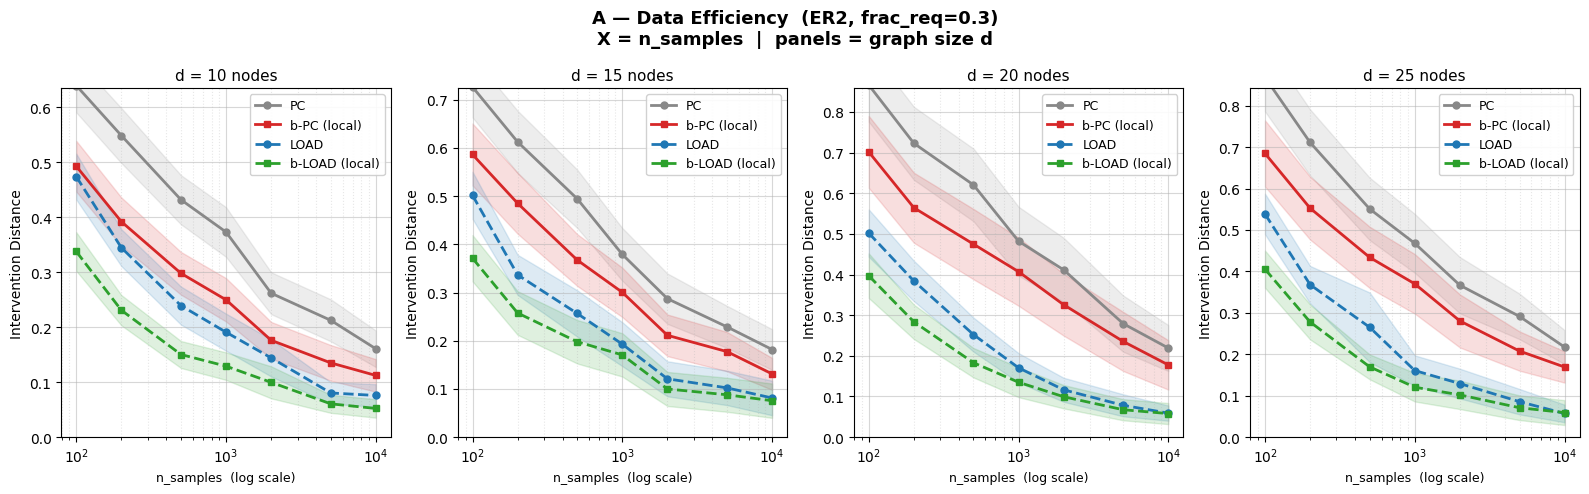

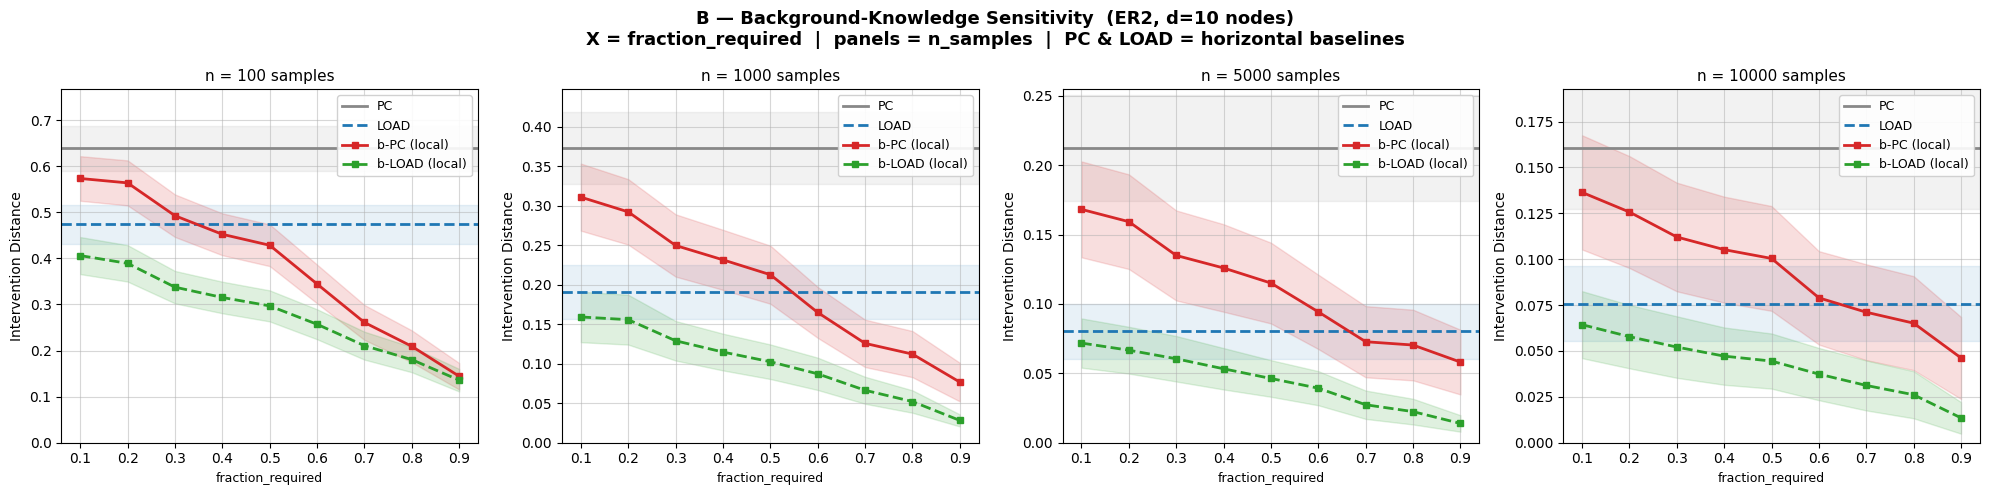

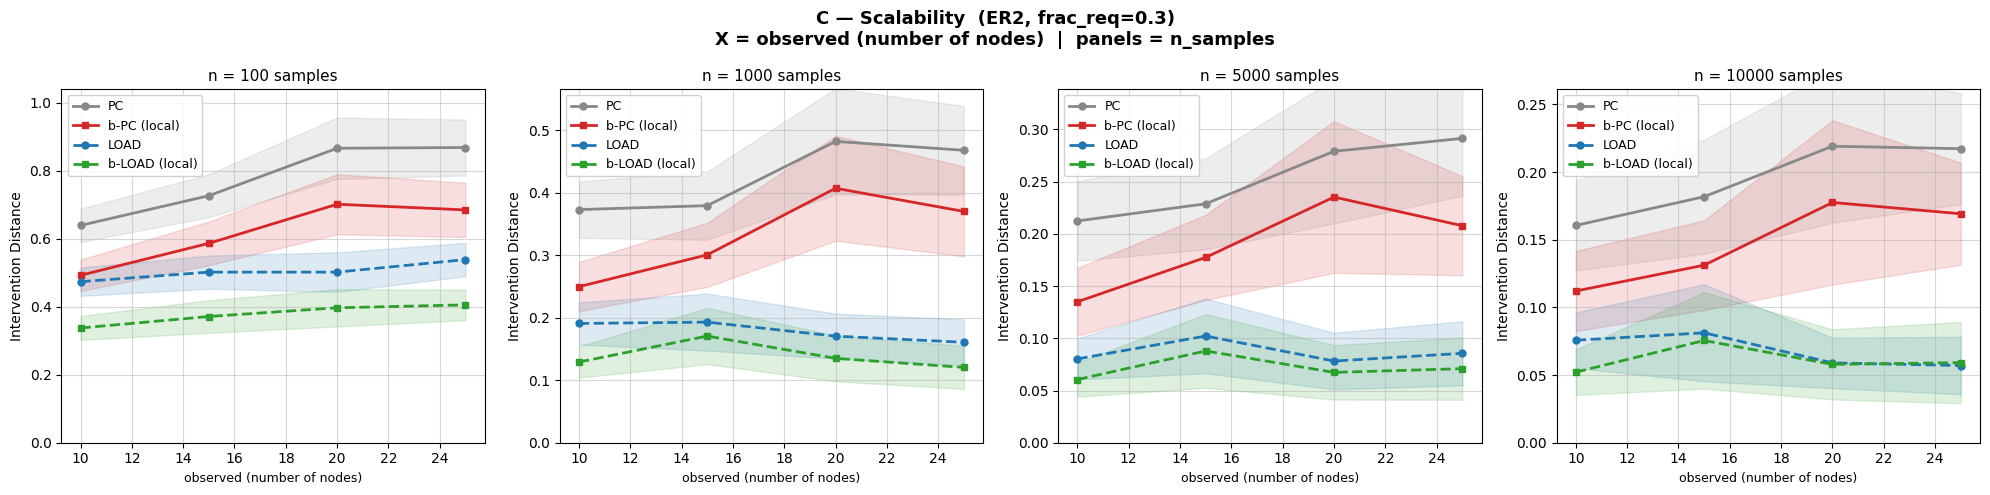

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  Intervention Distance — three axes of comparison (all fixed to ER2)
# ══════════════════════════════════════════════════════════════════════════════

ER = 2.0
df_pc_er2   = df_pc  [np.isclose(df_pc  ['exp_degree'], ER)].copy()
df_bpc_er2  = df_bpc [np.isclose(df_bpc ['exp_degree'], ER)].copy()
df_load_er2 = df_load[np.isclose(df_load['exp_degree'], ER)].copy()

COLORS = {
    'pc':    '#888888',
    'bpc':   '#d62728',
    'load':  '#1f77b4',
    'bload': '#2ca02c',
}

def _pline(ax, x, y, ci, color, label, linestyle='-', marker='o', alpha=0.15):
    ax.plot(x, y, color=color, label=label, linestyle=linestyle,
            marker=marker, markersize=5, linewidth=2)
    ax.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)

def _cap_ylim(ax, *series, pct=95, margin=1.20):
    """Set y-axis from 0 to (pct-th percentile) × margin of all shown means."""
    all_vals = [v for s in series for v in s if not np.isnan(v)]
    if all_vals:
        ax.set_ylim(bottom=0, top=np.nanpercentile(all_vals, pct) * margin)

def _fmt(ax, title, xlabel, xscale='linear', legend_loc='upper right'):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Intervention Distance', fontsize=10)
    ax.set_xscale(xscale)
    ax.grid(True, which='major', linestyle='-',  alpha=0.5)
    ax.grid(True, which='minor', linestyle=':',  alpha=0.3)
    ax.legend(fontsize=9, framealpha=0.9, loc=legend_loc)

# ─────────────────────────────────────────────────────────────────────────────
# OPTION A — Data efficiency
#   Fixed : ER2, fraction_required = 0.3
#   X-axis: n_samples (log)
#   Panels: one per graph size d ∈ {10, 15, 20, 25}
# ─────────────────────────────────────────────────────────────────────────────
FRAC_A = 0.3
D_A    = [10, 15, 20, 25]

fig_a, axes_a = plt.subplots(1, len(D_A), figsize=(16, 5), sharey=False)
fig_a.suptitle(
    f'A — Data Efficiency  (ER2, frac_req={FRAC_A})\n'
    'X = n_samples  |  panels = graph size d',
    fontsize=13, fontweight='bold',
)

for ax, d in zip(axes_a, D_A):
    pc_s  = df_pc_er2 [df_pc_er2 ['observed'] == d].sort_values('n_samples')
    bpc_s = df_bpc_er2[(df_bpc_er2['observed'] == d) &
                        np.isclose(df_bpc_er2['fraction_required'], FRAC_A)].sort_values('n_samples')
    lo_s  = (df_load_er2[df_load_er2['observed'] == d]
             .drop_duplicates('n_samples').sort_values('n_samples'))
    blo_s = df_load_er2[(df_load_er2['observed'] == d) &
                         np.isclose(df_load_er2['fraction_required'], FRAC_A)].sort_values('n_samples')

    _pline(ax, pc_s ['n_samples'], pc_s ['int_dist_mean'],          pc_s ['ci_int_dist'],
           COLORS['pc'],    'PC',             linestyle='-',  marker='o')
    if not bpc_s.empty:
        _pline(ax, bpc_s['n_samples'], bpc_s['int_dist_mean'],          bpc_s['ci_int_dist'],
               COLORS['bpc'],   'b-PC (local)',   linestyle='-',  marker='s')
    _pline(ax, lo_s ['n_samples'], lo_s ['int_dist_without_b_mean'], lo_s ['ci_int_dist_without_b'],
           COLORS['load'],  'LOAD',            linestyle='--', marker='o')
    if not blo_s.empty:
        _pline(ax, blo_s['n_samples'], blo_s['int_dist_with_b_mean'],   blo_s['ci_int_dist_with_b'],
               COLORS['bload'], 'b-LOAD (local)', linestyle='--', marker='s')

    _cap_ylim(ax,
              pc_s ['int_dist_mean'],
              lo_s ['int_dist_without_b_mean'],
              bpc_s['int_dist_mean']          if not bpc_s.empty else [],
              blo_s['int_dist_with_b_mean']   if not blo_s.empty else [])
    _fmt(ax, f'd = {d} nodes', 'n_samples  (log scale)', xscale='log', legend_loc='upper right')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# OPTION B — Background-knowledge sensitivity
#   Fixed : ER2, d = 10
#   X-axis: fraction_required
#   Panels: one per n_samples ∈ {100, 1000, 5000, 10000}
#   PC / LOAD drawn as horizontal reference lines (BK-invariant)
# ─────────────────────────────────────────────────────────────────────────────
D_B    = 10
N_B    = [n for n in [100, 1000, 5000, 10000] if n in df_bpc_er2['n_samples'].values]

fig_b, axes_b = plt.subplots(1, len(N_B), figsize=(5 * len(N_B), 5), sharey=False)
if len(N_B) == 1: axes_b = [axes_b]
fig_b.suptitle(
    f'B — Background-Knowledge Sensitivity  (ER2, d={D_B} nodes)\n'
    'X = fraction_required  |  panels = n_samples  |  PC & LOAD = horizontal baselines',
    fontsize=13, fontweight='bold',
)

for ax, n in zip(axes_b, N_B):
    pc_row  = df_pc_er2 [(df_pc_er2 ['observed'] == D_B) & (df_pc_er2 ['n_samples'] == n)]
    bpc_s   = df_bpc_er2[(df_bpc_er2['observed'] == D_B) & (df_bpc_er2['n_samples'] == n)].sort_values('fraction_required')
    lo_rows = df_load_er2[(df_load_er2['observed'] == D_B) & (df_load_er2['n_samples'] == n)]
    blo_s   = lo_rows.sort_values('fraction_required')
    lo_row  = lo_rows.drop_duplicates('n_samples')

    # Horizontal reference lines for BK-invariant methods
    if not pc_row.empty:
        pc_y, pc_ci = pc_row['int_dist_mean'].iloc[0], pc_row['ci_int_dist'].iloc[0]
        ax.axhline(pc_y, color=COLORS['pc'], linewidth=2, linestyle='-',  label='PC')
        ax.axhspan(pc_y - pc_ci, pc_y + pc_ci, color=COLORS['pc'],  alpha=0.10)
    if not lo_row.empty:
        lo_y, lo_ci = lo_row['int_dist_without_b_mean'].iloc[0], lo_row['ci_int_dist_without_b'].iloc[0]
        ax.axhline(lo_y, color=COLORS['load'], linewidth=2, linestyle='--', label='LOAD')
        ax.axhspan(lo_y - lo_ci, lo_y + lo_ci, color=COLORS['load'], alpha=0.10)

    if not bpc_s.empty:
        _pline(ax, bpc_s['fraction_required'], bpc_s['int_dist_mean'],          bpc_s['ci_int_dist'],
               COLORS['bpc'],   'b-PC (local)',   linestyle='-',  marker='s')
    if not blo_s.empty:
        _pline(ax, blo_s['fraction_required'], blo_s['int_dist_with_b_mean'],   blo_s['ci_int_dist_with_b'],
               COLORS['bload'], 'b-LOAD (local)', linestyle='--', marker='s')

    _cap_ylim(ax,
              pc_row['int_dist_mean']               if not pc_row.empty else [],
              lo_row['int_dist_without_b_mean']      if not lo_row.empty else [],
              bpc_s ['int_dist_mean']               if not bpc_s.empty  else [],
              blo_s ['int_dist_with_b_mean']         if not blo_s.empty  else [],
              pct=100)
    _fmt(ax, f'n = {n} samples', 'fraction_required', legend_loc='upper right')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# OPTION C — Scalability
#   Fixed : ER2, fraction_required = 0.3
#   X-axis: observed (graph size d)
#   Panels: one per n_samples ∈ {100, 1000, 5000, 10000}
# ─────────────────────────────────────────────────────────────────────────────
FRAC_C = 0.3
N_C    = [n for n in [100, 1000, 5000, 10000] if n in df_bpc_er2['n_samples'].values]

fig_c, axes_c = plt.subplots(1, len(N_C), figsize=(5 * len(N_C), 5), sharey=False)
if len(N_C) == 1: axes_c = [axes_c]
fig_c.suptitle(
    f'C — Scalability  (ER2, frac_req={FRAC_C})\n'
    'X = observed (number of nodes)  |  panels = n_samples',
    fontsize=13, fontweight='bold',
)

for ax, n in zip(axes_c, N_C):
    pc_s  = df_pc_er2 [df_pc_er2 ['n_samples'] == n].sort_values('observed')
    bpc_s = df_bpc_er2[(df_bpc_er2['n_samples'] == n) &
                        np.isclose(df_bpc_er2['fraction_required'], FRAC_C)].sort_values('observed')
    lo_s  = (df_load_er2[df_load_er2['n_samples'] == n]
             .drop_duplicates('observed').sort_values('observed'))
    blo_s = df_load_er2[(df_load_er2['n_samples'] == n) &
                         np.isclose(df_load_er2['fraction_required'], FRAC_C)].sort_values('observed')

    _pline(ax, pc_s ['observed'], pc_s ['int_dist_mean'],          pc_s ['ci_int_dist'],
           COLORS['pc'],    'PC',             linestyle='-',  marker='o')
    if not bpc_s.empty:
        _pline(ax, bpc_s['observed'], bpc_s['int_dist_mean'],          bpc_s['ci_int_dist'],
               COLORS['bpc'],   'b-PC (local)',   linestyle='-',  marker='s')
    _pline(ax, lo_s ['observed'], lo_s ['int_dist_without_b_mean'], lo_s ['ci_int_dist_without_b'],
           COLORS['load'],  'LOAD',            linestyle='--', marker='o')
    if not blo_s.empty:
        _pline(ax, blo_s['observed'], blo_s['int_dist_with_b_mean'],   blo_s['ci_int_dist_with_b'],
               COLORS['bload'], 'b-LOAD (local)', linestyle='--', marker='s')

    _cap_ylim(ax,
              pc_s ['int_dist_mean'],
              lo_s ['int_dist_without_b_mean'],
              bpc_s['int_dist_mean']          if not bpc_s.empty else [],
              blo_s['int_dist_with_b_mean']   if not blo_s.empty else [])
    _fmt(ax, f'n = {n} samples', 'observed (number of nodes)', legend_loc='upper left')

plt.tight_layout()
plt.show()

## On real datasets